# MGMT 590 — LendingClub Loan Default Risk (Indiana Borrowers)
## Phase 4B: Borrower Segmentation & Customer Profiling

**Course:** MGMT 59000, Summer 2026, Section DY2 — Purdue University

**Builds on:** Phase 1 (data pipeline), Phase 2 (EDA), Phase 3 (supervised
models), Phase 4A (`ExplainabilityEngine`, `RiskScoringEngine`,
configurable thresholds).

**Scope of this notebook:** develop a complete borrower-segmentation
framework using four new reusable Phase 4B modules --
`src/cluster_analysis.py`, `src/cluster_visualization.py`,
`src/segment_profiles.py`, `src/segmentation_engine.py` -- demonstrated
against the Phase 1 training split. Instead of predicting whether ONE
borrower will default, this phase identifies NATURAL borrower groups
with similar financial characteristics, complementing (not replacing)
Phase 3's supervised models.

**Not implemented here (explicitly deferred):** the Streamlit dashboard
(Phase 5).

> **Note on data:** as in Phases 1-4A, this notebook runs against
> whatever is currently at `data/splits/` and `models/`. If these still
> reflect the synthetic test fixture rather than the real ~37,515-row
> Indiana LendingClub extract, treat every specific segment name,
> profile number, and business claim below as illustrative of the
> *mechanism* only -- re-run Phases 1, 3, 4A, and this notebook once the
> genuine data is in place. Segment names in particular are assigned
> from the DATA (see Section 6), so on synthetic (effectively random)
> data they may not carry the same real-world meaning they would on
> genuine borrower data.


In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, utils
from src import cluster_analysis as ca
from src import cluster_visualization as cv
from src import segment_profiles as sprof
from src.segmentation_engine import SegmentationEngine
from src.risk_scoring import RiskScoringEngine

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = utils.load_splits()
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Production model: {config.PRODUCTION_MODEL_KEY}")


2026-08-01 04:03:57 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_train.csv — shape=(1049, 21)


2026-08-01 04:03:57 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_val.csv — shape=(226, 21)


2026-08-01 04:03:57 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_test.csv — shape=(225, 21)


2026-08-01 04:03:57 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_train.csv — shape=(1049, 1)


2026-08-01 04:03:57 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_val.csv — shape=(226, 1)


2026-08-01 04:03:57 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_test.csv — shape=(225, 1)


Train: (1049, 21) | Val: (226, 21) | Test: (225, 21)
Production model: xgboost


## 1. Data Preparation for Clustering

### Which features drive cluster membership, and why

Clustering uses **numeric + ordinal features only**
(`config.CLUSTERING_NUMERIC_FEATURES` + `config.CLUSTERING_ORDINAL_FEATURES`
-- 14 numeric financial characteristics plus `grade`), deliberately
**excluding** the one-hot categorical columns (`home_ownership`,
`purpose`, `verification_status`, `term`, `application_type`,
`initial_list_status`) that drive the SUPERVISED models in Phase 3.

**Why excluded from clustering distance:** one-hot dummy columns are
binary (0/1); under Euclidean distance, several correlated dummies from
the same categorical variable can collectively dominate the distance
calculation over genuinely continuous financial signals like income or
DTI, producing clusters that mostly reproduce a categorical variable's
own categories rather than revealing new financial-behavior groupings.

**Why still valuable:** every excluded categorical column is fully used
downstream, in PROFILING each segment (Section 7) -- "what does Segment
2 typically look like" still reports typical home ownership, loan
purpose, etc. -- just not as an input to *defining* segment membership.

### Feature scaling
`StandardScaler` (z-score standardization), not `MinMaxScaler`: every
feature must contribute comparably to Euclidean distance regardless of
its native units (dollars vs. years vs. a percentage) -- without
scaling, `annual_inc` (tens of thousands) would dominate `dti` (a
percentage) in any distance-based clustering algorithm.

### Categorical encoding
`grade` is ordinal-encoded (A < B < ... < G, consistent with Phase 1's
encoding) then scaled alongside the numeric features, since it carries a
genuine ordering relevant to distance. Other categoricals are one-hot in
Phase 3's supervised pipeline but are excluded here entirely (see above).

### Outlier treatment
IQR-based winsorization (clip, not drop) at a wide 3x IQR multiplier --
K-Means and hierarchical clustering both use Euclidean distance, where a
single extreme value can pull a centroid or merge decision noticeably. A
wider multiplier than the classical 1.5x boxplot rule is used
deliberately, since 1.5x IQR would flag a large share of financial data
(income, revolving balance) as "outliers" when it is simply
legitimately right-skewed borrower variation. Clipping (not dropping)
means every borrower keeps a segment assignment.

### Dimensionality reduction
Evaluated separately in Section 2 below, purely for VISUALIZATION --
clustering itself operates on the full standardized feature space, not
a reduced-dimension projection (see Section 2 for why).


In [3]:
clipped_train = ca.clip_outliers(X_train)
n_clipped_features = sum(
    1 for col in config.CLUSTERING_NUMERIC_FEATURES
    if not np.allclose(clipped_train[col].to_numpy(), X_train[col].to_numpy(), equal_nan=True)
)
print(f"Clustering features: {len(config.CLUSTERING_NUMERIC_FEATURES)} numeric + {len(config.CLUSTERING_ORDINAL_FEATURES)} ordinal")
print(f"Features with at least one clipped outlier value: {n_clipped_features}")


2026-08-01 04:03:57 | INFO     | src.cluster_analysis | Clipped 4 outlier values in 'annual_inc' to [-60861.29, 162750.59].


2026-08-01 04:03:57 | INFO     | src.cluster_analysis | Clipped 147 outlier values in 'pub_rec' to [0.00, 0.00].


2026-08-01 04:03:57 | INFO     | src.cluster_analysis | Clipped 93 outlier values in 'pub_rec_bankruptcies' to [0.00, 0.00].


Clustering features: 14 numeric + 1 ordinal
Features with at least one clipped outlier value: 3


In [4]:
clustering_preprocessor = ca.build_clustering_preprocessor()
X_clustering = clustering_preprocessor.fit_transform(clipped_train)
print(f"Clustering feature matrix shape: {X_clustering.shape}")


2026-08-01 04:03:57 | INFO     | src.cluster_analysis | Built clustering preprocessor: 14 numeric + 1 ordinal features (categorical one-hot columns excluded).


Clustering feature matrix shape: (1049, 15)


## 2. Dimensionality Reduction: PCA vs. t-SNE vs. UMAP

All three are computed here for comparison, using a temporary K-Means(k=4)
labeling purely to color the scatter plots for visual comparison (the
engine's own fit, with the properly-selected k, happens in Section 4).

- **PCA**: a LINEAR projection preserving GLOBAL variance structure;
  deterministic; has a reusable `.transform()` for new data. Best when
  the axes themselves need stable, interpretable meaning across re-runs.
- **t-SNE**: preserves LOCAL neighborhood structure well but NOT global
  distances; no `.transform()` for new data (every run re-embeds
  jointly); best for visual cluster-separation sanity-checks only.
- **UMAP**: preserves both local AND some global structure better than
  t-SNE, and DOES support `.transform()` on new data.


In [5]:
quick_labels = ca.fit_kmeans(X_clustering, n_clusters=4).labels

pca_result = ca.fit_pca(X_clustering)
print(f"PCA: {pca_result.explained_variance_ratio.sum():.1%} of variance explained by 2 components")

sample_size = min(config.DIMENSIONALITY_REDUCTION_SAMPLE_SIZE, len(X_clustering))
rng = np.random.default_rng(config.RANDOM_STATE)
sample_idx = rng.choice(len(X_clustering), size=sample_size, replace=False)

tsne_result = ca.fit_tsne(X_clustering[sample_idx])
umap_result = ca.fit_umap(X_clustering[sample_idx])
print("t-SNE and UMAP fit on a", sample_size, "row sample for interactive speed.")


2026-08-01 04:03:57 | INFO     | src.cluster_analysis | Fitted PCA(n_components=2): explained variance ratio = [0.089 0.086] (total 17.5%)


PCA: 17.5% of variance explained by 2 components


2026-08-01 04:04:02 | INFO     | src.cluster_analysis | Fitted t-SNE on 1000 samples (perplexity=30.0).


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | Fitted UMAP on 1000 samples (n_neighbors=15, min_dist=0.10).


t-SNE and UMAP fit on a 1000 row sample for interactive speed.


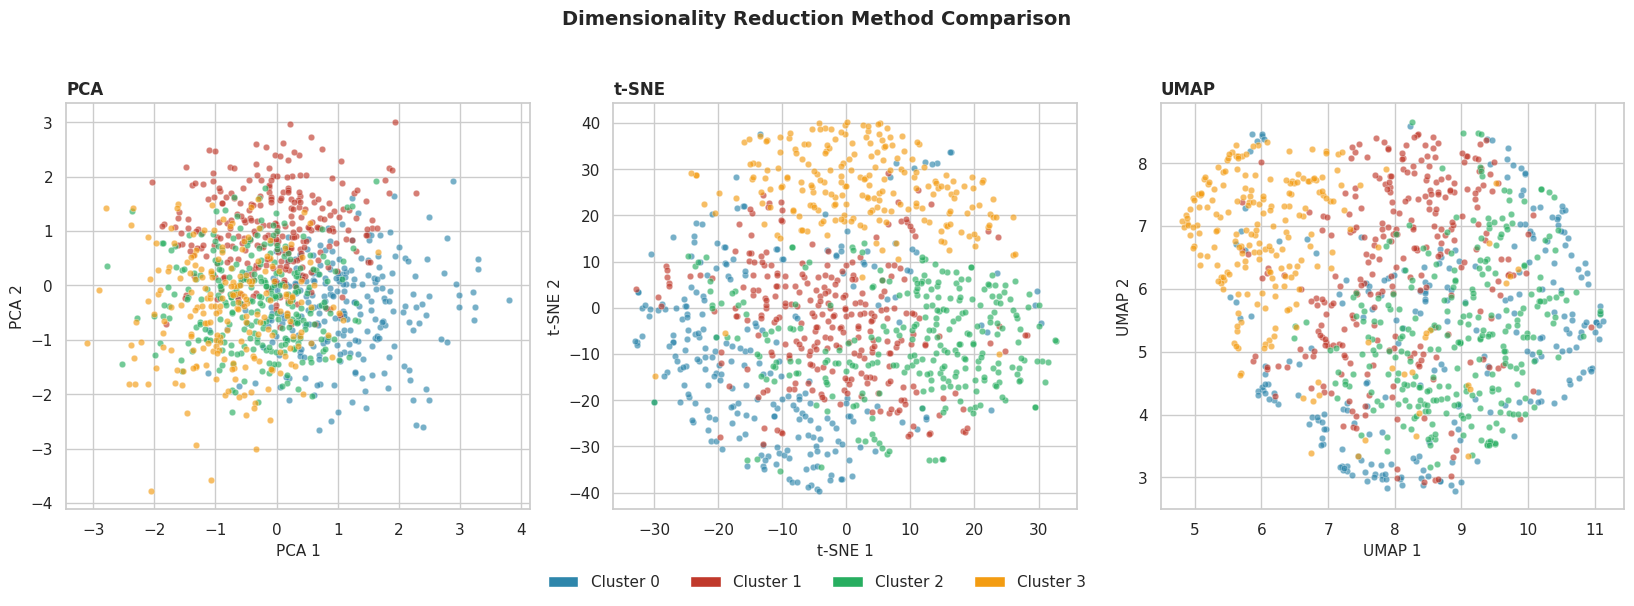

In [6]:
results = {"PCA": pca_result.coordinates[sample_idx], "t-SNE": tsne_result.coordinates}
if umap_result is not None:
    results["UMAP"] = umap_result.coordinates

fig = cv.plot_dimensionality_reduction_comparison(results, quick_labels[sample_idx])
plt.show()


**Comparison and recommendation:** PCA's 2 components typically explain
a modest share of total variance for this feature count (printed above)
-- expected, since borrower financial characteristics are genuinely
multi-dimensional rather than dominated by one or two axes. t-SNE/UMAP
often show visually tighter, more separated clusters than PCA precisely
BECAUSE they optimize for local separation rather than preserving true
distances -- useful for a compelling executive visual, but PCA's linear,
reusable projection is recommended as the PRIMARY method for this
project's ongoing visualizations (Section 5), since it can be
`.transform()`-ed consistently for any new borrower batch without
re-embedding the whole population, which t-SNE cannot do at all and
UMAP can do but at additional complexity. t-SNE/UMAP remain valuable
SECONDARY visual sanity-checks, shown here for comparison.


## 3. Determining the Optimal Number of Clusters

Four methods evaluated across k = 2 to 8:
- **Elbow method** (inertia): look for where adding another cluster
  stops reducing within-cluster variance much -- a visual judgment call.
- **Silhouette score**: higher is better (well-separated, cohesive clusters).
- **Calinski-Harabasz index**: higher is better (tends to favor MORE clusters).
- **Davies-Bouldin index**: LOWER is better (tends to favor FEWER, more compact clusters).


In [7]:
optimal_k_table = ca.evaluate_optimal_k(X_clustering, k_candidates=config.N_CLUSTERS_CANDIDATES)
optimal_k_table


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=2: inertia=12819.4, silhouette=0.060, calinski_harabasz=66.8, davies_bouldin=3.892


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=3: inertia=12172.0, silhouette=0.059, calinski_harabasz=62.9, davies_bouldin=3.502


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=4: inertia=11687.3, silhouette=0.053, calinski_harabasz=58.1, davies_bouldin=3.090


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=5: inertia=11275.0, silhouette=0.057, calinski_harabasz=54.7, davies_bouldin=2.904


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=6: inertia=10937.3, silhouette=0.056, calinski_harabasz=51.5, davies_bouldin=2.720


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=7: inertia=10647.8, silhouette=0.061, calinski_harabasz=48.8, davies_bouldin=2.591


2026-08-01 04:04:13 | INFO     | src.cluster_analysis | k=8: inertia=10415.5, silhouette=0.059, calinski_harabasz=46.0, davies_bouldin=2.523


,n_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,"12,819.3641",0.0597,66.7790,3.8915
1,3,"12,172.0068",0.0587,62.9470,3.5017
2,4,"11,687.2807",0.0531,58.1104,3.0904
3,5,"11,275.0105",0.0572,54.6766,2.9040
4,6,"10,937.3464",0.0559,51.4885,2.7200
5,7,"10,647.7993",0.0605,48.7542,2.5913
6,8,"10,415.4556",0.0592,45.9980,2.5229


In [8]:
recommended_k, explanation = ca.recommend_optimal_k(optimal_k_table)
print(explanation)


k=7 has the best average rank (3.00) across silhouette (rank 1), Calinski-Harabasz (rank 6), and Davies-Bouldin (rank 2) among candidates [2, 3, 4, 5, 6, 7, 8].


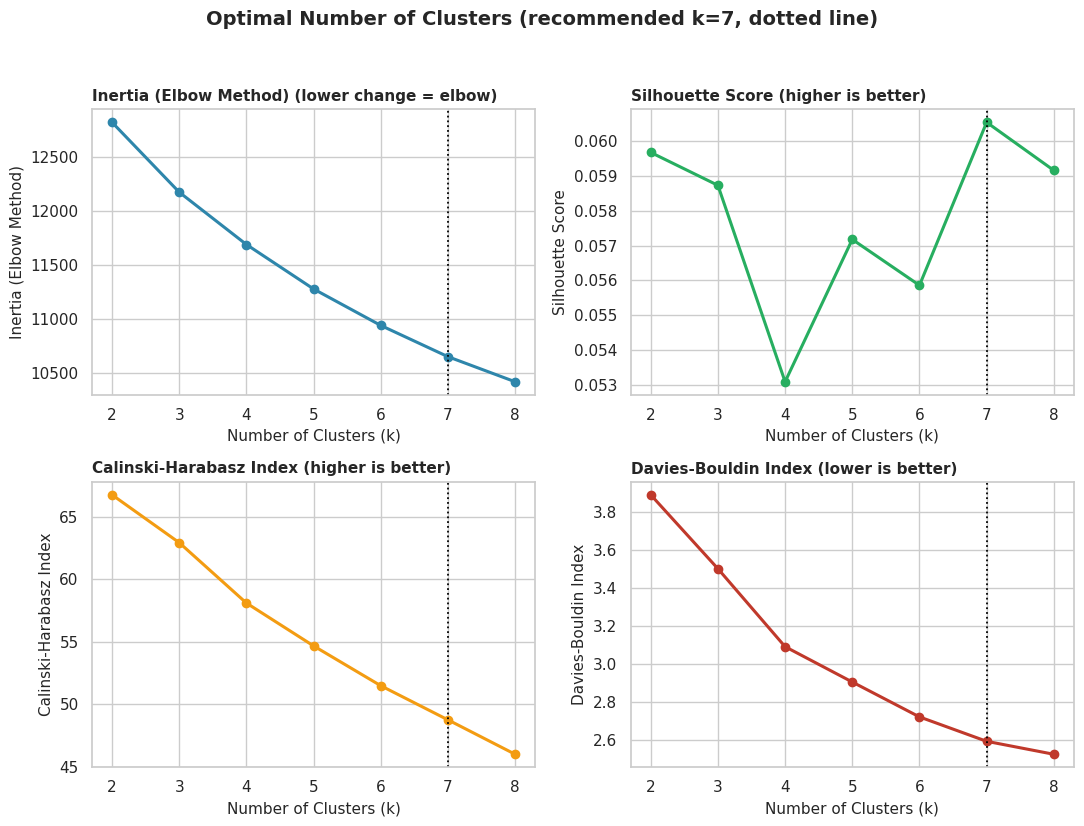

In [9]:
fig = cv.plot_optimal_k_analysis(optimal_k_table, recommended_k)
plt.show()


**Justification for the final cluster count:** rather than trusting
any single metric (each has known biases -- Calinski-Harabasz tends to
favor more clusters, Davies-Bouldin fewer), the recommendation above
averages each candidate k's RANK across silhouette, Calinski-Harabasz,
and Davies-Bouldin. The elbow method is reported alongside for visual
corroboration but excluded from the vote itself, since "the elbow" is a
visual judgment call without one unambiguous numeric rule.
`config.DEFAULT_N_CLUSTERS` reflects a business-driven choice of 4
segments as a reasonable, actionable number for underwriting policy and
marketing strategy -- `SegmentationEngine.fit(..., auto_select_k=True)`
is also available to defer entirely to the statistical recommendation
above.

## 4. Clustering Algorithms Comparison

Four algorithms compared at the recommended k using the same validity
metrics as Section 3. Full advantages/disadvantages/business-
applicability/computational-considerations discussion lives in each
function's docstring in `src/cluster_analysis.py`
(`fit_kmeans`, `fit_agglomerative`, `fit_gaussian_mixture`, `fit_dbscan`).


In [10]:
algorithm_comparison_rows = []
for name, fit_fn in [("K-Means", ca.fit_kmeans), ("Agglomerative", ca.fit_agglomerative), ("Gaussian Mixture", ca.fit_gaussian_mixture)]:
    result = fit_fn(X_clustering, n_clusters=recommended_k)
    metrics = ca.evaluate_clustering(X_clustering, result.labels)
    algorithm_comparison_rows.append({"algorithm": name, "n_clusters_found": result.n_clusters, **metrics})

# DBSCAN doesn't take a target k -- included separately with a representative eps/min_samples.
dbscan_result = ca.fit_dbscan(X_clustering, eps=1.5, min_samples=10)
dbscan_metrics = ca.evaluate_clustering(X_clustering, dbscan_result.labels)
algorithm_comparison_rows.append({"algorithm": "DBSCAN", "n_clusters_found": dbscan_result.n_clusters, **dbscan_metrics})

pd.DataFrame(algorithm_comparison_rows)


2026-08-01 04:04:14 | WARNING  | src.cluster_analysis | Fewer than 2 clusters present -- validity metrics undefined.


,algorithm,n_clusters_found,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,K-Means,7,0.0605,48.7542,2.5913
1,Agglomerative,7,0.0173,30.6070,3.4435
2,Gaussian Mixture,7,0.0072,22.4072,3.0701
3,DBSCAN,0,NaN,NaN,NaN


**Business applicability summary:**
- **K-Means** (default): fast, produces convex/globular clusters that
  are easy to describe to a business audience ("borrowers near this
  centroid"); the right fit for reasonably continuous financial
  segments without highly irregular shapes.
- **Agglomerative Clustering**: useful as a CROSS-CHECK (does it agree
  with K-Means?) and for its dendrogram, but has no `.predict()` for new
  borrowers -- less suited as the deployed production algorithm.
- **Gaussian Mixture**: offers SOFT membership probabilities (a borrower
  can be 60% one segment, 40% another) -- a secondary lens for portfolio
  risk reporting when a hard boundary feels too rigid, but harder to
  explain to a non-technical audience than K-Means' simple
  nearest-centroid story.
- **DBSCAN**: typically produces one dominant cluster plus scattered
  noise on financial data that doesn't have well-separated density
  regions (borrower characteristics form a fairly continuous cloud) --
  the `n_clusters_found` above illustrates this limitation directly; not
  used as `SegmentationEngine`'s default algorithm for this reason.

**K-Means is used as `SegmentationEngine`'s default algorithm** for the
remainder of this notebook, consistent with `config.DEFAULT_CLUSTERING_ALGORITHM`.


## 5. Fitting the Segmentation Engine

`SegmentationEngine` composes everything above (data preparation,
clustering, dimensionality reduction, profiling, business naming) into
one reusable, Streamlit-ready class -- mirroring `RiskScoringEngine` and
`ExplainabilityEngine`'s design from Phase 4A.

In [11]:
engine = SegmentationEngine(n_clusters=recommended_k, algorithm="kmeans")
engine.fit(X_train, default_flags=y_train)
print(f"Fitted {engine.n_clusters} segments: {list(engine.fit_result.segment_names.values())}")


2026-08-01 04:04:14 | INFO     | src.configurable_thresholds | Loaded risk threshold configuration from /home/claude/mgmt590_capstone/reports/risk_threshold_config.json


2026-08-01 04:04:14 | INFO     | src.configurable_thresholds | Risk threshold configuration validated successfully.


2026-08-01 04:04:14 | INFO     | src.segmentation_engine | SegmentationEngine constructed: algorithm=kmeans, n_clusters=7


2026-08-01 04:04:14 | INFO     | src.segmentation_engine | Fitting SegmentationEngine on 1049 borrowers.


2026-08-01 04:04:14 | INFO     | src.cluster_analysis | Clipped 4 outlier values in 'annual_inc' to [-60861.29, 162750.59].


...

2026-08-01 04:04:14 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/threshold_analysis.joblib


2026-08-01 04:04:14 | INFO     | src.risk_scoring | RiskScoringEngine ready: model=XGBoost, decision_threshold=0.05


2026-08-01 04:04:14 | INFO     | src.segment_profiles | Assigned data-driven segment names: {3: 'High Risk Borrowers', np.int64(5): 'Prime Borrowers', np.int64(2): 'High Debt Borrowers', 1: 'Moderate Risk Borrowers (1)', 4: 'Moderate Risk Borrowers (2)', 0: 'Moderate Risk Borrowers (3)', 6: 'Moderate Risk Borrowers (4)'}


2026-08-01 04:04:14 | INFO     | src.segmentation_engine | SegmentationEngine fit complete: 7 segments -> {3: 'High Risk Borrowers', np.int64(5): 'Prime Borrowers', np.int64(2): 'High Debt Borrowers', 1: 'Moderate Risk Borrowers (1)', 4: 'Moderate Risk Borrowers (2)', 0: 'Moderate Risk Borrowers (3)', 6: 'Moderate Risk Borrowers (4)'}


Fitted 7 segments: ['High Risk Borrowers', 'Prime Borrowers', 'High Debt Borrowers', 'Moderate Risk Borrowers (1)', 'Moderate Risk Borrowers (2)', 'Moderate Risk Borrowers (3)', 'Moderate Risk Borrowers (4)']


## 6. Cluster Visualizations

2026-08-01 04:04:14 | INFO     | src.cluster_analysis | Clipped 4 outlier values in 'annual_inc' to [-60861.29, 162750.59].


2026-08-01 04:04:14 | INFO     | src.cluster_analysis | Clipped 147 outlier values in 'pub_rec' to [0.00, 0.00].


2026-08-01 04:04:14 | INFO     | src.cluster_analysis | Clipped 93 outlier values in 'pub_rec_bankruptcies' to [0.00, 0.00].


2026-08-01 04:04:14 | INFO     | src.cluster_analysis | Fitted PCA(n_components=2): explained variance ratio = [0.089 0.086] (total 17.5%)


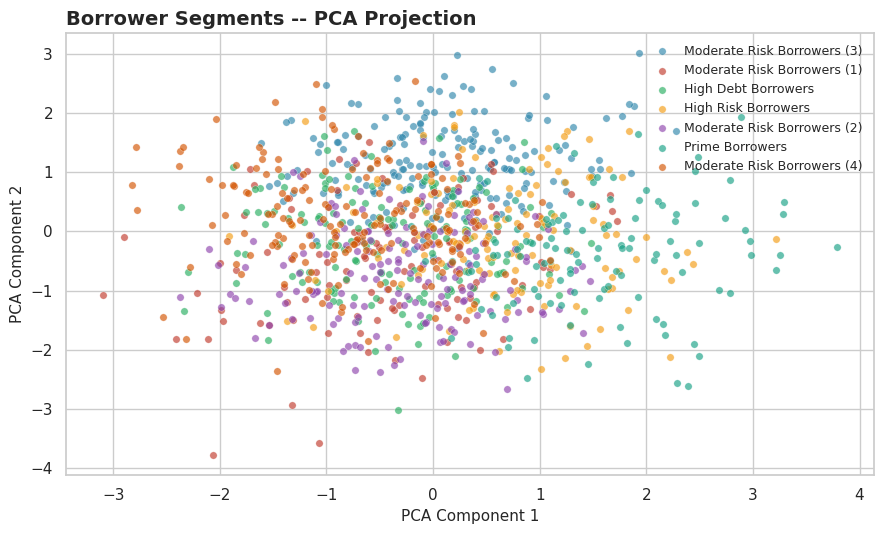

In [12]:
fig = engine.visualize_clusters(method="pca")
plt.show()


**Business interpretation:** each color is one borrower segment; the
axes are the two directions of greatest variance in the standardized
financial-characteristic feature space. Visually distinct, non-
overlapping colored regions indicate the segments are genuinely
separable financial profiles rather than an arbitrary partition.

2026-08-01 04:04:15 | INFO     | src.cluster_analysis | Clipped 4 outlier values in 'annual_inc' to [-60861.29, 162750.59].


2026-08-01 04:04:15 | INFO     | src.cluster_analysis | Clipped 147 outlier values in 'pub_rec' to [0.00, 0.00].


2026-08-01 04:04:15 | INFO     | src.cluster_analysis | Clipped 93 outlier values in 'pub_rec_bankruptcies' to [0.00, 0.00].


2026-08-01 04:04:19 | INFO     | src.cluster_analysis | Fitted t-SNE on 1000 samples (perplexity=30.0).


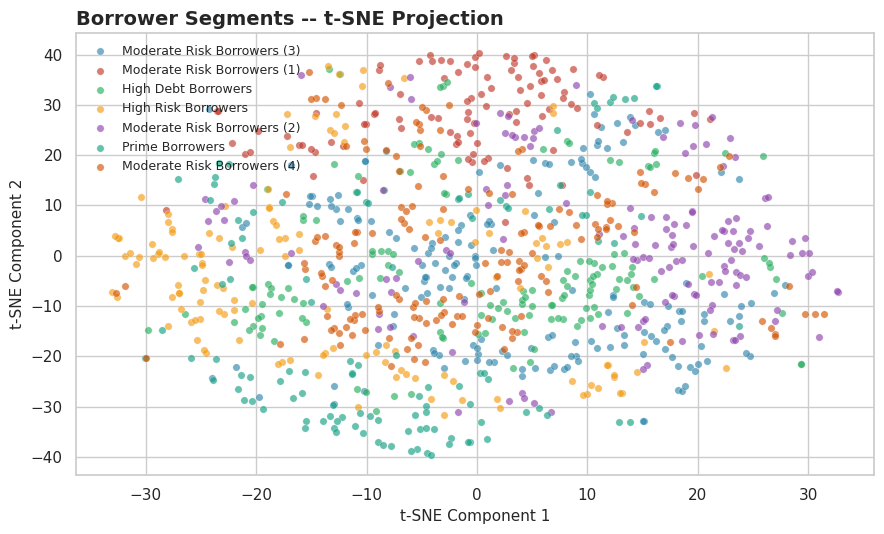

In [13]:
fig = engine.visualize_clusters(method="tsne")
plt.show()


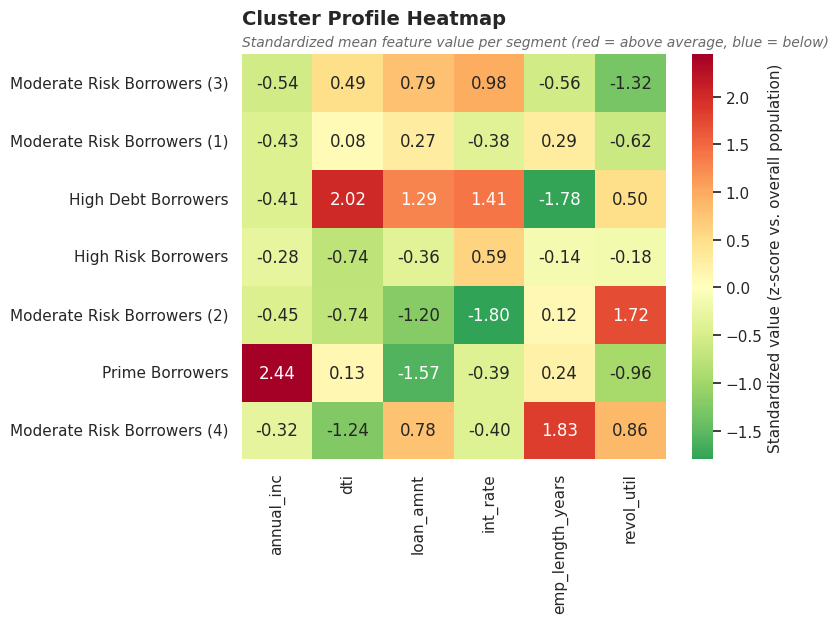

In [14]:
profile_features = ["annual_inc", "dti", "loan_amnt", "int_rate", "emp_length_years", "revol_util"]
profile_df = X_train.copy()
profile_df["cluster"] = engine.fit_result.labels

fig = cv.plot_cluster_heatmap(profile_df, profile_features, segment_names=engine.fit_result.segment_names)
plt.show()


**Business interpretation:** red cells mean that segment is ABOVE the
overall-population average on that feature; blue means below. Reading
across one row gives that segment's full financial "signature" at a
glance.

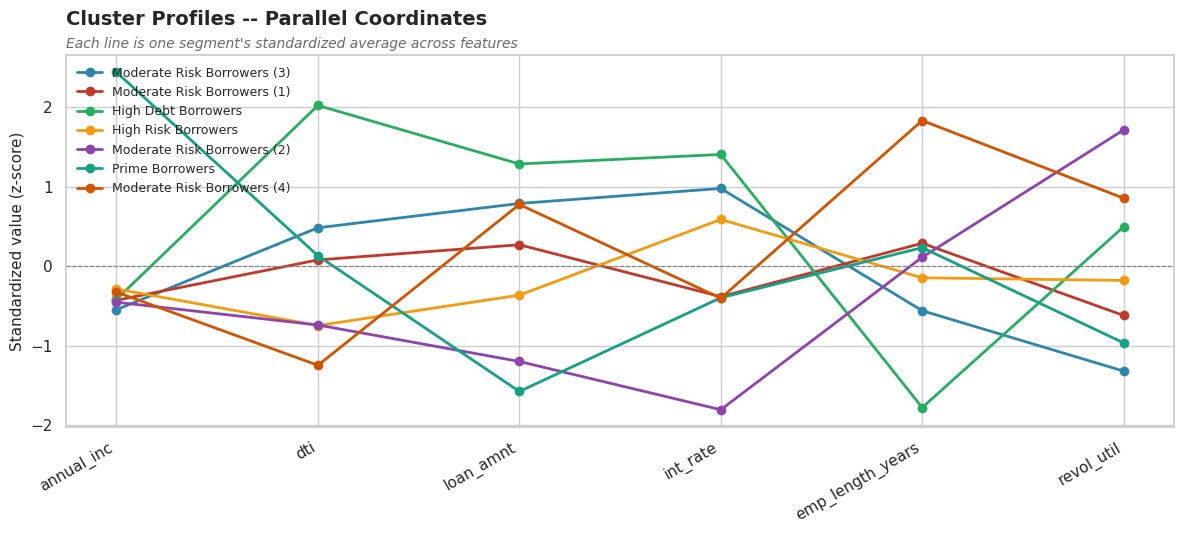

In [15]:
fig = cv.plot_parallel_coordinates(profile_df, profile_features, segment_names=engine.fit_result.segment_names)
plt.show()


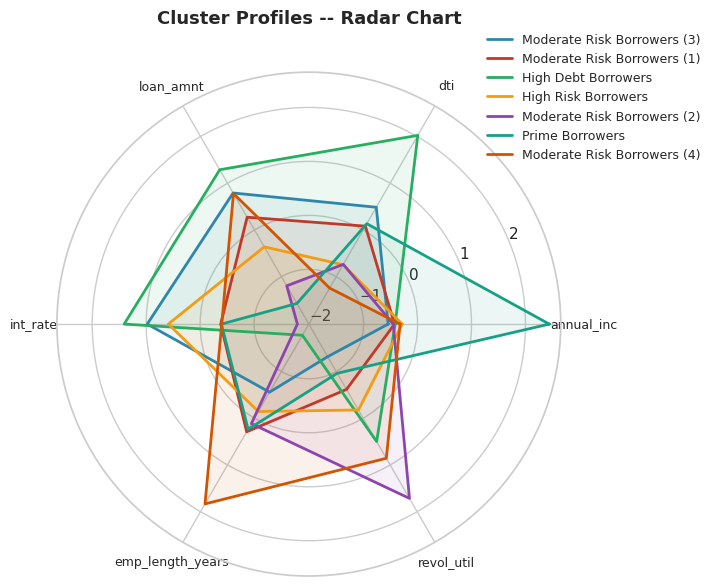

In [16]:
fig = cv.plot_radar_chart(profile_df, profile_features, segment_names=engine.fit_result.segment_names)
plt.show()


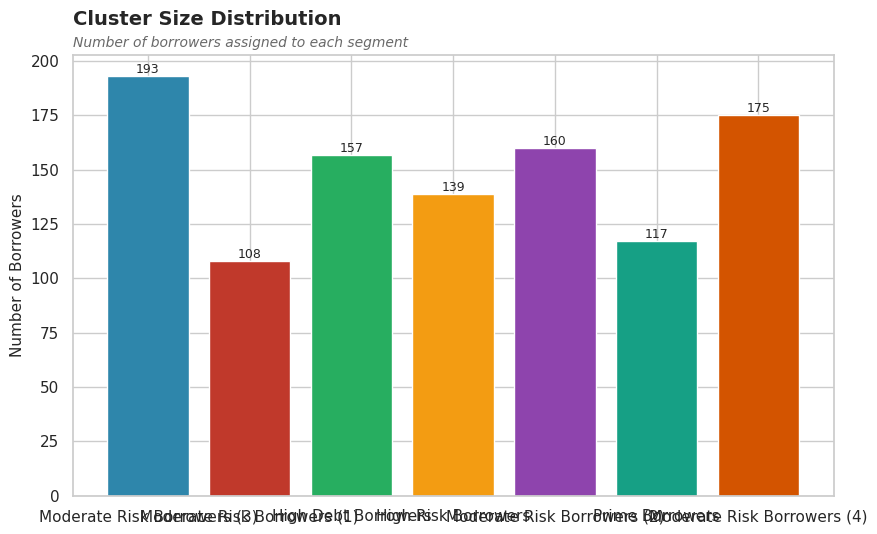

In [17]:
fig = cv.plot_cluster_size_distribution(engine.fit_result.labels, segment_names=engine.fit_result.segment_names)
plt.show()


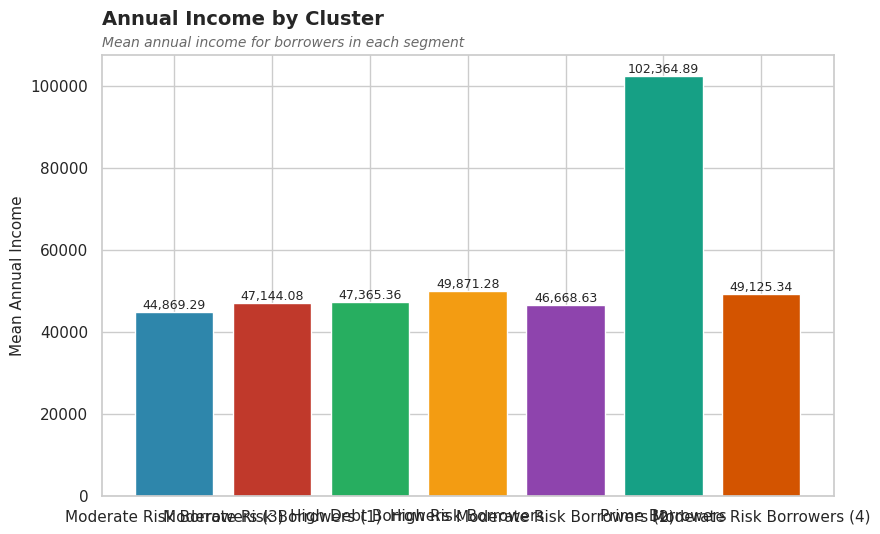

In [18]:
fig = cv.plot_feature_by_cluster(profile_df, "annual_inc", segment_names=engine.fit_result.segment_names, feature_label="Annual Income")
plt.show()


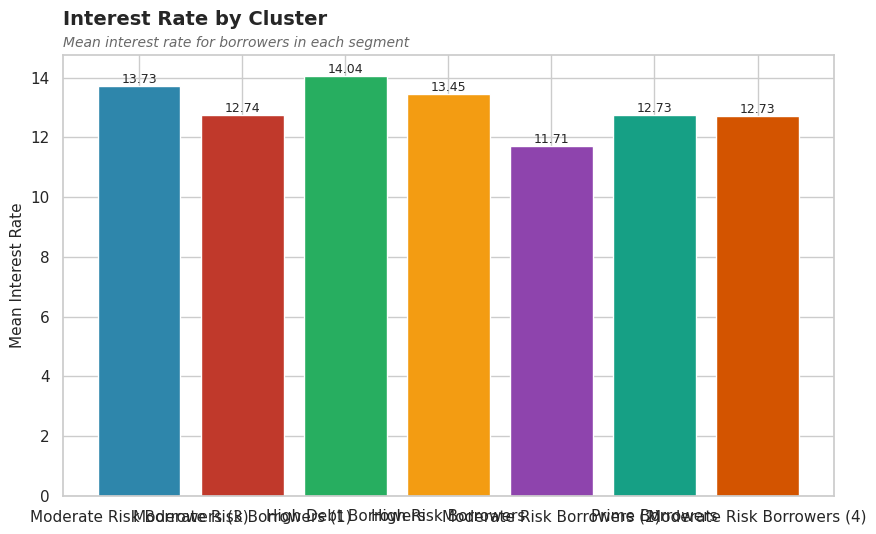

In [19]:
fig = cv.plot_feature_by_cluster(profile_df, "int_rate", segment_names=engine.fit_result.segment_names, feature_label="Interest Rate")
plt.show()


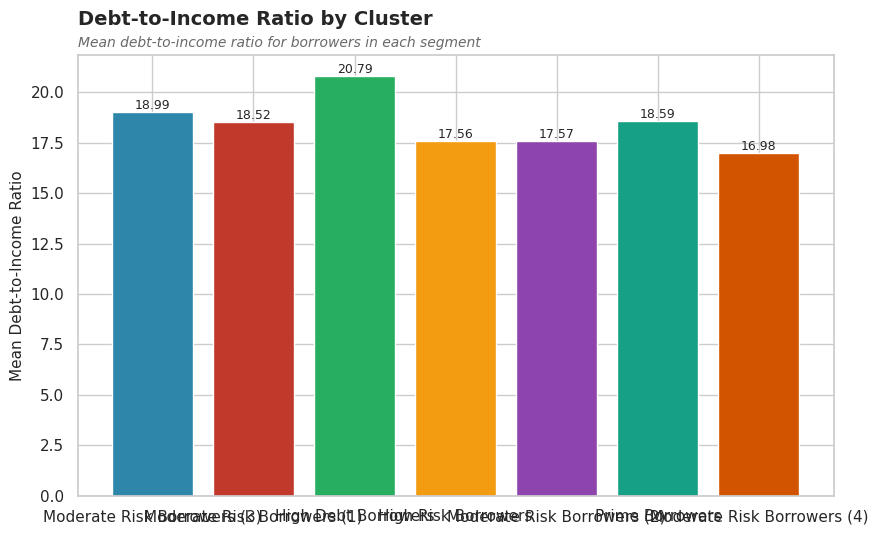

In [20]:
fig = cv.plot_feature_by_cluster(profile_df, "dti", segment_names=engine.fit_result.segment_names, feature_label="Debt-to-Income Ratio")
plt.show()


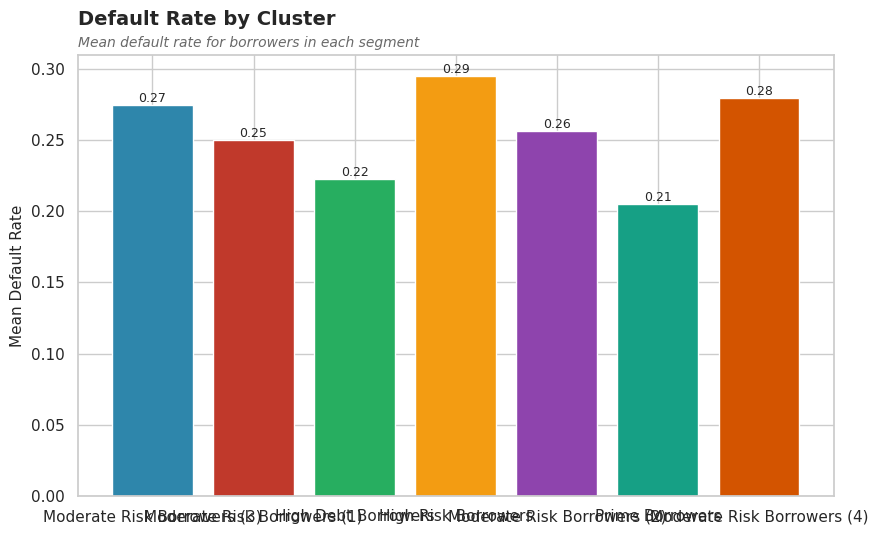

In [21]:
profile_df_with_default = profile_df.copy()
profile_df_with_default["default_flag"] = y_train.to_numpy()
fig = cv.plot_feature_by_cluster(profile_df_with_default, "default_flag", segment_names=engine.fit_result.segment_names, feature_label="Default Rate")
plt.show()


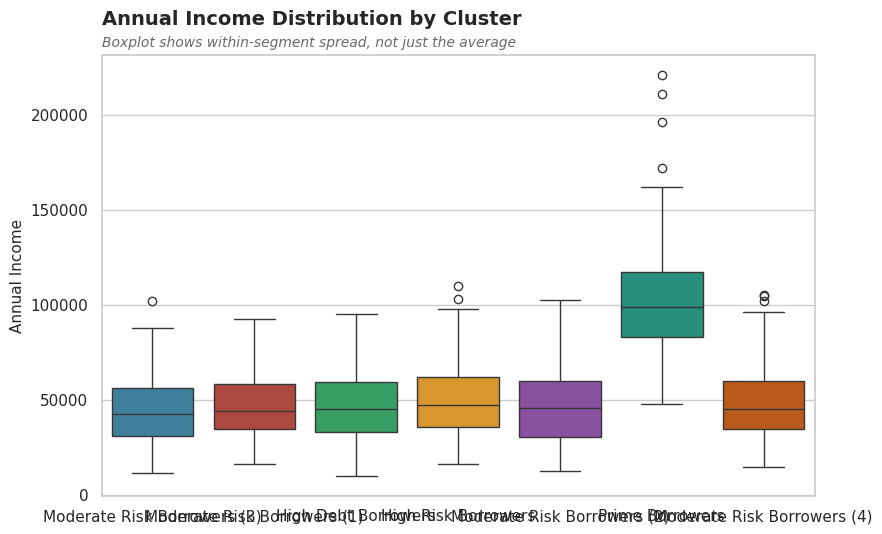

In [22]:
fig = cv.plot_feature_distribution_by_cluster(profile_df, "annual_inc", segment_names=engine.fit_result.segment_names, feature_label="Annual Income")
plt.show()


**Business interpretation:** the boxplot reveals within-segment
SPREAD that a bar-of-means chart hides -- two segments can have similar
average income but very different variability, which matters for how
tightly a lending policy can be tailored to that segment.

## 7. Comprehensive Cluster Profiles

Every segment's typical income, DTI, loan amount, interest rate, grade,
employment length, home ownership, loan purpose, default rate, and
credit characteristics.

In [23]:
engine.generate_cluster_profile()


,n_borrowers,pct_of_portfolio,annual_inc,dti,loan_amnt,int_rate,emp_length_years,revol_util,revol_bal,open_acc,total_acc,mort_acc,grade,home_ownership,purpose,average_default_rate
cluster,,,,,,,,,,,,,,,,
0,193,0.1840,"44,869.2948",18.9948,"23,558.2487",13.7318,4.0112,31.9606,"17,542.5026",9.7565,40.3834,4.7306,B,RENT,debt_consolidation,0.2746
1,108,0.1030,"47,144.0817",18.5242,"21,849.1389",12.7442,5.0778,39.1685,"31,417.7593",16.0463,31.3519,3.0278,B,RENT,debt_consolidation,0.2500
2,157,0.1497,"47,365.3601",20.7865,"25,193.9172",14.0420,2.4795,50.6624,"39,589.6242",9.2293,29.5350,1.3567,A,MORTGAGE,debt_consolidation,0.2229
3,139,0.1325,"49,871.2849",17.5627,"19,762.1079",13.4486,4.5317,43.7036,"30,778.0935",12.7986,34.7842,3.1079,E,MORTGAGE,debt_consolidation,0.2950
4,160,0.1525,"46,668.6347",17.5709,"17,015.8500",11.7126,4.8571,63.2006,"18,634.3563",16.1750,20.0000,3.2687,B,RENT,debt_consolidation,0.2562
5,117,0.1115,"102,364.8904",18.5851,"15,774.0171",12.7343,5.0091,35.6154,"28,081.6838",15.2821,32.1795,2.6923,A,MORTGAGE,debt_consolidation,0.2051
6,175,0.1668,"49,125.3391",16.9808,"23,516.7543",12.7299,7.0187,54.3520,"44,079.3371",9.3086,28.8000,4.9257,A,MORTGAGE,debt_consolidation,0.2800


In [24]:
for cluster_id in sorted(engine.fit_result.profiles.keys()):
    print(engine.describe_segment(cluster_id))
    print()


Moderate Risk Borrowers (3) (193 borrowers, 18.4% of the portfolio) typically have $44,869 in annual income, a 19.0% debt-to-income ratio, and take $23,558 loans at a 13.7% interest rate (typical grade: B). Most are rent homeowners/renters seeking loans for debt consolidation, with 4.0 years of typical employment tenure. This segment shows an average default rate of 27.5% and is classified as Moderate Risk.

Moderate Risk Borrowers (1) (108 borrowers, 10.3% of the portfolio) typically have $47,144 in annual income, a 18.5% debt-to-income ratio, and take $21,849 loans at a 12.7% interest rate (typical grade: B). Most are rent homeowners/renters seeking loans for debt consolidation, with 5.1 years of typical employment tenure. This segment shows an average default rate of 25.0% and is classified as Moderate Risk.

High Debt Borrowers (157 borrowers, 15.0% of the portfolio) typically have $47,365 in annual income, a 20.8% debt-to-income ratio, and take $25,194 loans at a 14.0% interest ra

## 8. Data-Driven Business Segment Names

Names are assigned FROM THE DATA (relative income/DTI/interest-rate/
default-rate z-scores across segments -- see
`segment_profiles.assign_segment_names`'s docstring for the exact
priority logic), never fixed in advance independent of the numbers.

In [25]:
pd.Series(engine.fit_result.segment_names, name="segment_name").to_frame()


,segment_name
3,High Risk Borrowers
5,Prime Borrowers
2,High Debt Borrowers
1,Moderate Risk Borrowers (1)
4,Moderate Risk Borrowers (2)
0,Moderate Risk Borrowers (3)
6,Moderate Risk Borrowers (4)


## 9. Business Recommendations by Segment

For every segment: primary risk level, lending recommendation, interest-
rate strategy, underwriting strategy, manual-review requirement,
marketing strategy, and portfolio-management notes.

In [26]:
recommendations_table = pd.DataFrame([r.to_dict() for r in engine.recommend_business_actions().values()])
recommendations_table


,cluster_id,segment_name,primary_risk_level,lending_recommendation,interest_rate_strategy,underwriting_strategy,manual_review_requirement,marketing_strategy,portfolio_management_notes
0,0,Moderate Risk Borrowers (3),Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...
1,1,Moderate Risk Borrowers (1),Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...
2,2,High Debt Borrowers,Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...
3,3,High Risk Borrowers,Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...
4,4,Moderate Risk Borrowers (2),Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...
5,5,Prime Borrowers,Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...
6,6,Moderate Risk Borrowers (4),Moderate Risk,Approve with standard conditions; monitor for ...,Price at or slightly above the base rate to re...,Standard underwriting with routine income/empl...,Spot-check a sample of applications; full revi...,Target with rate-competitive offers conditione...,Represents the core of the portfolio; track de...


## 10. Segment Comparison Table

Income, interest rate, loan grade, DTI, employment length, default rate,
risk tier, and cluster size for every segment side-by-side.

In [27]:
engine.compare_segments()


,segment_name,n_borrowers,pct_of_portfolio,typical_income,typical_interest_rate,typical_loan_grade,typical_dti,typical_employment_length,average_default_rate,risk_tier
0,High Risk Borrowers,139,0.1325,"49,871.2849",13.4486,E,17.5627,4.5317,0.2950,Moderate Risk
1,Moderate Risk Borrowers (4),175,0.1668,"49,125.3391",12.7299,A,16.9808,7.0187,0.2800,Moderate Risk
2,Moderate Risk Borrowers (3),193,0.1840,"44,869.2948",13.7318,B,18.9948,4.0112,0.2746,Moderate Risk
3,Moderate Risk Borrowers (2),160,0.1525,"46,668.6347",11.7126,B,17.5709,4.8571,0.2562,Moderate Risk
4,Moderate Risk Borrowers (1),108,0.1030,"47,144.0817",12.7442,B,18.5242,5.0778,0.2500,Moderate Risk
5,High Debt Borrowers,157,0.1497,"47,365.3601",14.0420,A,20.7865,2.4795,0.2229,Moderate Risk
6,Prime Borrowers,117,0.1115,"102,364.8904",12.7343,A,18.5851,5.0091,0.2051,Moderate Risk


**How segments differ:** the table above is sorted by default rate
(riskiest first). Segments with similar interest rates but different
default rates suggest the CURRENT LendingClub-assigned grade/rate isn't
fully capturing the risk differentiation this clustering reveals --
directly relevant to Research Question 2 (are LendingClub grades
predictive?) and a candidate input for repricing policy.

## 11. Relationship to the Supervised Machine Learning Models

Do high-risk clusters align with high PREDICTED default probabilities
from Phase 3's production model? Which clusters concentrate the most
actual defaults?

In [28]:
ml_comparison = engine.compare_with_supervised_models()
ml_comparison[["segment_name", "n_borrowers", "mean_predicted_probability", "average_default_rate", "risk_tier"]]


,segment_name,n_borrowers,mean_predicted_probability,average_default_rate,risk_tier
0,High Risk Borrowers,139,0.3369,0.2950,Moderate Risk
1,Moderate Risk Borrowers (3),193,0.3154,0.2746,Moderate Risk
2,Moderate Risk Borrowers (4),175,0.3041,0.2800,Moderate Risk
3,Moderate Risk Borrowers (2),160,0.2978,0.2562,Moderate Risk
4,Moderate Risk Borrowers (1),108,0.2958,0.2500,Moderate Risk
5,High Debt Borrowers,157,0.2577,0.2229,Moderate Risk
6,Prime Borrowers,117,0.2345,0.2051,Moderate Risk


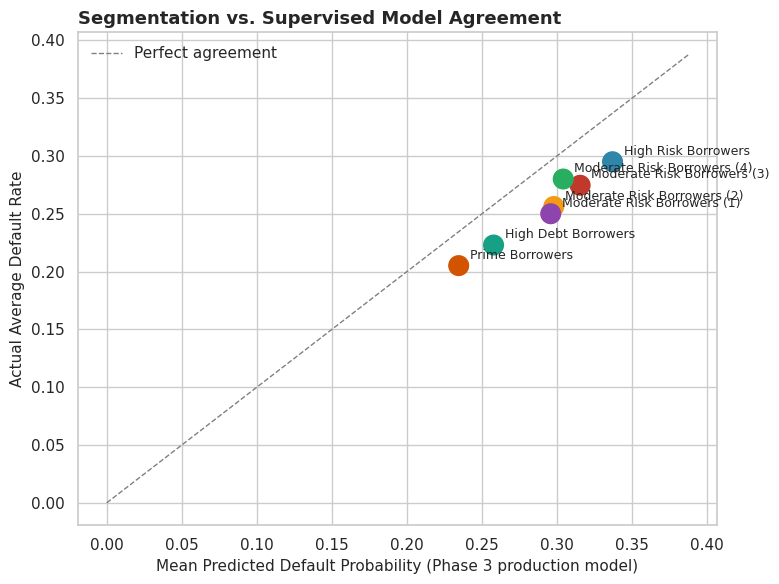

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ml_comparison["mean_predicted_probability"], ml_comparison["average_default_rate"], s=200,
           c=[cv._cluster_color(i) for i in range(len(ml_comparison))])
for _, row in ml_comparison.iterrows():
    ax.annotate(row["segment_name"], (row["mean_predicted_probability"], row["average_default_rate"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
lims = [0, max(ml_comparison["mean_predicted_probability"].max(), ml_comparison["average_default_rate"].max()) * 1.15]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="Perfect agreement")
ax.set_xlabel("Mean Predicted Default Probability (Phase 3 production model)")
ax.set_ylabel("Actual Average Default Rate")
ax.set_title("Segmentation vs. Supervised Model Agreement", fontsize=13, fontweight="bold", loc="left")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


**Business interpretation:**
- **Do high-risk clusters align with high predicted default probabilities?**
  Segments falling near the diagonal reference line show strong
  agreement between the UNSUPERVISED clustering (based purely on
  financial-profile similarity) and the SUPERVISED model's learned risk
  ranking -- meaningful validation that both approaches are picking up
  the same underlying risk signal from different angles.
- **Which clusters contain the greatest concentration of defaults?**
  The segment(s) highest on both axes.
- **Can clustering explain patterns not captured by supervised learning?**
  A segment with a notably HIGHER actual default rate than its mean
  predicted probability would suggest the supervised model under-prices
  that specific financial-profile combination -- exactly the kind of
  gap segmentation is well-suited to surface, since it groups by overall
  profile similarity rather than a single learned probability.
- **How should Lending Club use both together?** The supervised model
  remains the primary basis for an INDIVIDUAL lending decision (it uses
  the full feature space and is validated against actual outcomes via
  Phase 3's metrics); segmentation adds a PORTFOLIO-level and POLICY-level
  lens -- setting origination limits, marketing strategy, and
  underwriting policy tiers by segment, informed by (and cross-checked
  against) the supervised model's risk ranking.


## 12. Research Question Support

**Which borrower segments represent the highest lending risk?**
Directly answered by Section 10's comparison table (sorted by default
rate) and Section 11's supervised-model cross-check -- the segment(s) at
the top of both rankings represent the highest lending risk, supported
by BOTH the segment's own historical default rate AND independent
agreement from the supervised production model's predicted probability.
This is a more robust conclusion than either signal alone, since the two
methods use different information (financial-profile similarity vs.
learned outcome prediction) and their agreement is itself evidence the
finding is not an artifact of one particular method.


## 13. Exportable Segment Reports

`SegmentationEngine.export_segment_summary()` returns an
`interpretation_utils.ExportableReport` -- `.to_markdown()` / `.to_json()`
output is ready for a future Streamlit `st.download_button()`.

In [30]:
segment_report = engine.export_segment_summary()
print(segment_report.to_markdown()[:2500])


# Borrower Segmentation Report

## Executive Summary

Borrower segmentation identified 7 distinct groups with meaningfully different financial profiles and lending risk. High Risk Borrowers carries the highest observed default rate (29.5%, 139 borrowers), while Prime Borrowers shows the lowest (20.5%, 117 borrowers). These segments complement (rather than replace) the supervised default-risk models: clustering groups borrowers by overall financial profile, which can guide underwriting policy and marketing strategy at the segment level even where an individual borrower's predicted probability, from Phase 3's models, remains the primary basis for a specific lending decision.

## Segment Comparison

| segment_name | n_borrowers | pct_of_portfolio | typical_income | typical_interest_rate | typical_loan_grade | typical_dti | typical_employment_length | average_default_rate | risk_tier |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| High Risk Borrowers | 139 | 0.1325 | 49,8

## 14. Persisting Reusable Segmentation Artifacts

`SegmentationEngine.persist_segmentation_artifacts()` serializes the
fitted clustering model, clustering preprocessor, cluster centroids,
segment definitions (profile + recommendation per cluster), cluster
metadata, the segment-profile table, and the optimal-k analysis table --
everything a future Streamlit dashboard needs without recomputing
clustering from scratch.

In [31]:
engine.persist_segmentation_artifacts()

print("Saved artifacts:")
print(f"  Clustering model:         {config.CLUSTERING_MODEL_PATH}")
print(f"  Clustering preprocessor:  {config.CLUSTERING_PREPROCESSOR_PATH}")
print(f"  Cluster centroids:        {config.CLUSTER_CENTROIDS_PATH}")
print(f"  Segment definitions:      {config.SEGMENT_DEFINITIONS_PATH}")
print(f"  Cluster metadata:         {config.CLUSTER_METADATA_PATH}")
print(f"  Segment profiles table:  {config.SEGMENT_PROFILES_PATH}")
print(f"  Optimal-k analysis:       {config.OPTIMAL_K_ANALYSIS_PATH}")


2026-08-01 04:04:21 | INFO     | src.utils | Verified 11 project directories exist.


2026-08-01 04:04:21 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/models/clustering_model.joblib


2026-08-01 04:04:21 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/segmentation/clustering_preprocessor.joblib


2026-08-01 04:04:21 | INFO     | src.cluster_analysis | Clipped 4 outlier values in 'annual_inc' to [-60861.29, 162750.59].


2026-08-01 04:04:21 | INFO     | src.cluster_analysis | Clipped 147 outlier values in 'pub_rec' to [0.00, 0.00].


...

2026-08-01 04:04:21 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/segmentation/cluster_metadata.joblib


2026-08-01 04:04:21 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/segmentation/segment_profiles.joblib


2026-08-01 04:04:21 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/segmentation/optimal_k_analysis.joblib


2026-08-01 04:04:21 | INFO     | src.segmentation_engine | All Phase 4B segmentation artifacts persisted to /home/claude/mgmt590_capstone/reports/segmentation / /home/claude/mgmt590_capstone/models


Saved artifacts:
  Clustering model:         /home/claude/mgmt590_capstone/models/clustering_model.joblib
  Clustering preprocessor:  /home/claude/mgmt590_capstone/reports/segmentation/clustering_preprocessor.joblib
  Cluster centroids:        /home/claude/mgmt590_capstone/reports/segmentation/cluster_centroids.joblib
  Segment definitions:      /home/claude/mgmt590_capstone/reports/segmentation/segment_definitions.joblib
  Cluster metadata:         /home/claude/mgmt590_capstone/reports/segmentation/cluster_metadata.joblib
  Segment profiles table:  /home/claude/mgmt590_capstone/reports/segmentation/segment_profiles.joblib
  Optimal-k analysis:       /home/claude/mgmt590_capstone/reports/segmentation/optimal_k_analysis.joblib


## 15. Preparing for Phase 5 (Streamlit Dashboard)

### How borrower segmentation complements supervised learning

Phase 3's supervised models answer "what is THIS borrower's default
probability?" -- a precise, individually-validated prediction.
Segmentation answers a complementary question: "what natural GROUPS of
borrowers exist, and how do their overall financial profiles differ?"
Section 11 showed these two lenses agree directionally (high-predicted-
risk segments also show high actual default rates), which is itself
useful validation, while also giving Lending Club a portfolio/policy
tool (segment-level underwriting rules, marketing strategy, origination
limits) that a per-borrower probability alone doesn't provide.

### How `SegmentationEngine` will integrate into Streamlit

Every method returns either a `matplotlib.figure.Figure` (ready for
`st.pyplot(fig)`), a plain dataclass/DataFrame/string, or an
`interpretation_utils.ExportableReport` (ready for
`st.download_button()`). A borrower-detail page could call:

```python
engine = SegmentationEngine()  # cached via st.cache_resource; call .fit(X_train, y_train) once at startup
segment_name = engine.assign_segment(borrower_row).iloc[0]
st.metric("Borrower Segment", segment_name)
st.write(engine.describe_segment(cluster_id))
recommendation = engine.recommend_business_actions(cluster_id)
st.write(recommendation.lending_recommendation)
```

A portfolio-level page would call `engine.compare_segments()` and
`engine.visualize_clusters()` directly, and `engine.compare_with_supervised_models()`
to show the cross-validation view from Section 11.

### Public interfaces Phase 5 should use

| Module | Public interface |
|---|---|
| `src.cluster_analysis` | `build_clustering_preprocessor`, `clip_outliers`, `CLUSTERING_ALGORITHMS`, `evaluate_optimal_k`, `recommend_optimal_k` |
| `src.cluster_visualization` | `plot_dimensionality_reduction_scatter`, `plot_cluster_heatmap`, `plot_feature_by_cluster`, `plot_cluster_size_distribution` |
| `src.segment_profiles` | `SegmentProfile`, `SegmentRecommendation`, `build_segment_comparison_table` |
| `src.segmentation_engine` | `SegmentationEngine` (the primary interface -- fit once, then call any method above) |

### Explicitly deferred

- The Streamlit dashboard itself (Phase 5) — the architecture above is
  prepared for it; no dashboard code has been written in this phase.
- Integration testing, performance optimization, and deployment (Phase 6).
- Final code review, documentation, and presentation assets (Phase 7).
